In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.shape

(156612, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156612 entries, 0 to 156611
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    156612 non-null  float64
 1   V1      156612 non-null  float64
 2   V2      156611 non-null  float64
 3   V3      156611 non-null  float64
 4   V4      156611 non-null  float64
 5   V5      156611 non-null  float64
 6   V6      156611 non-null  float64
 7   V7      156611 non-null  float64
 8   V8      156611 non-null  float64
 9   V9      156611 non-null  float64
 10  V10     156611 non-null  float64
 11  V11     156611 non-null  float64
 12  V12     156611 non-null  float64
 13  V13     156611 non-null  float64
 14  V14     156611 non-null  float64
 15  V15     156611 non-null  float64
 16  V16     156611 non-null  float64
 17  V17     156611 non-null  float64
 18  V18     156611 non-null  float64
 19  V19     156611 non-null  float64
 20  V20     156611 non-null  float64
 21  V21     15

In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,1
V3,1
V4,1
V5,1
V6,1
V7,1
V8,1
V9,1


In [7]:
df['Class'].value_counts()

,count
Class,
0.0,156261
1.0,350


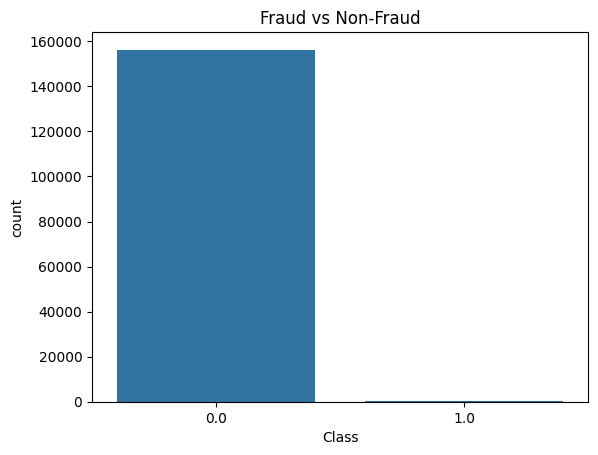

In [8]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

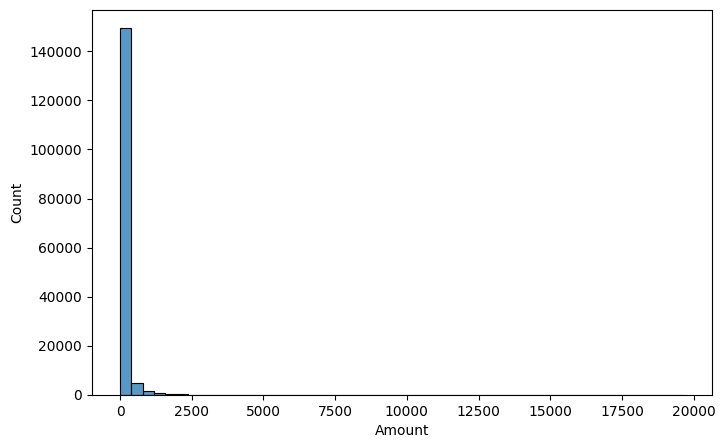

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50)
plt.show()

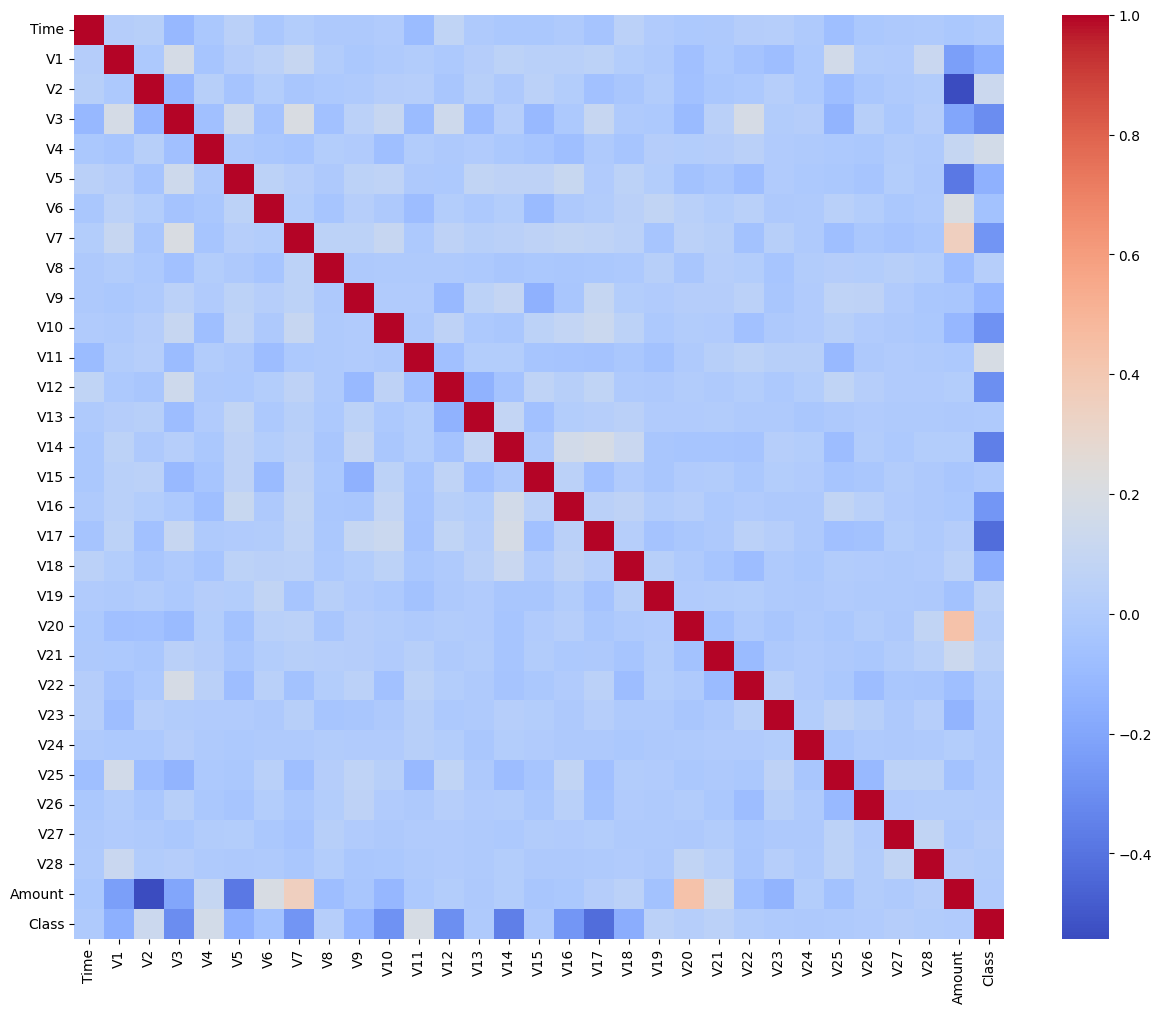

In [10]:
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [11]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [14]:
X = X.dropna()
y = y.dropna()

In [15]:
scaler = StandardScaler()

X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])

/tmp/ipykernel_2966/3649812574.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [20]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [22]:
print("Accuracy :", accuracy_score(y_test, pred_rf))

print("Precision :", precision_score(y_test, pred_rf))

print("Recall :", recall_score(y_test, pred_rf))

print("F1 Score :", f1_score(y_test, pred_rf))

Accuracy : 0.9995211186667944
Precision : 0.9508196721311475
Recall : 0.8285714285714286
F1 Score : 0.8854961832061069


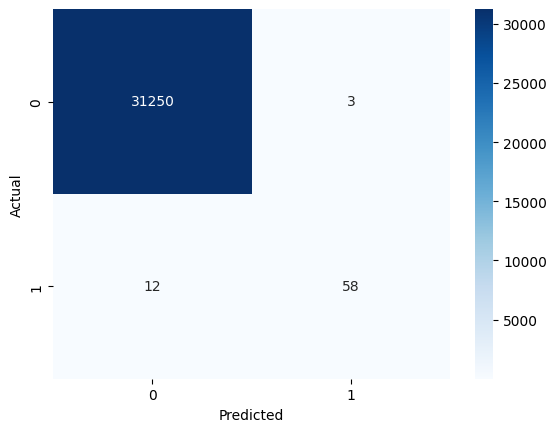

In [23]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     31253
         1.0       0.95      0.83      0.89        70

    accuracy                           1.00     31323
   macro avg       0.98      0.91      0.94     31323
weighted avg       1.00      1.00      1.00     31323



In [26]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.002,
    random_state=42
)

prediction = iso.fit_predict(X)

In [27]:
prediction = np.where(prediction==-1,1,0)

In [28]:
print(classification_report(y, prediction))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    156261
         1.0       0.43      0.39      0.41       350

    accuracy                           1.00    156611
   macro avg       0.72      0.69      0.70    156611
weighted avg       1.00      1.00      1.00    156611



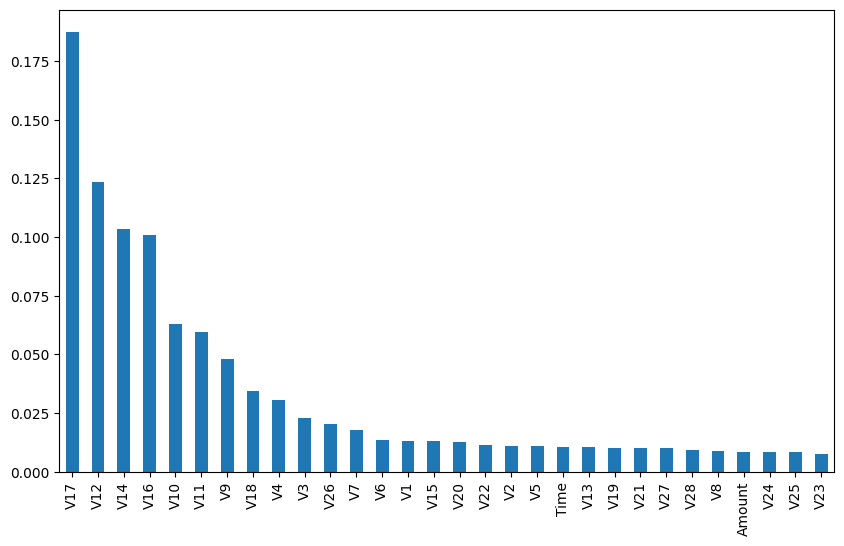

In [29]:
importance = rf.feature_importances_

features = X.columns

feature_imp = pd.Series(
    importance,
    index=features
).sort_values(ascending=False)

feature_imp.plot(kind='bar', figsize=(10,6))
plt.show()

In [30]:
new_transaction = X.iloc[[0]]

In [31]:
prediction = rf.predict(new_transaction)

if prediction[0]==1:
    print("Fraud Detected")
else:
    print("Legitimate Transaction")

Legitimate Transaction


In [32]:
models = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf
}

for name,pred in models.items():

    print(name)

    print("Accuracy :",accuracy_score(y_test,pred))

    print("Precision :",precision_score(y_test,pred))

    print("Recall :",recall_score(y_test,pred))

    print("F1 :",f1_score(y_test,pred))

    print("-"*40)

Logistic Regression
Accuracy : 0.9987549085336653
Precision : 0.803921568627451
Recall : 0.5857142857142857
F1 : 0.6776859504132231
----------------------------------------
Decision Tree
Accuracy : 0.999010311911375
Precision : 0.7746478873239436
Recall : 0.7857142857142857
F1 : 0.7801418439716312
----------------------------------------
Random Forest
Accuracy : 0.9995211186667944
Precision : 0.9508196721311475
Recall : 0.8285714285714286
F1 : 0.8854961832061069
----------------------------------------


Conclusion: This project successfully demonstrates the use of machine learning for detecting fraudulent credit card transactions. By applying data preprocessing, feature engineering, model training, and performance evaluation, the system effectively distinguishes between legitimate and fraudulent transactions. Such fraud detection systems can help financial institutions reduce monetary losses, improve customer trust, and enable secure, real-time transaction monitoring